# Data Preprocessing and Feature Engineering

This notebook prepares the obesity-risk dataset for machine-learning model development.

## Objectives

- Load the raw dataset without modifying it
- Separate predictive features from the target
- Remove non-predictive identifiers
- Create stratified training, validation, and test datasets
- Define numerical, ordinal, and nominal feature groups
- Build reusable preprocessing pipelines
- Prevent data leakage

In [130]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "obesity.csv"
)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System
Dataset path: c:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\data\raw\obesity.csv
Dataset exists: True


In [132]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

Dataset loaded successfully
Dataset shape: (20758, 18)


In [133]:
df.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [134]:
print("Columns:", df.columns.tolist())

Columns: ['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


In [135]:
identifier_column = "id"
target_column = "NObeyesdad"

print("Identifier column:", identifier_column)
print("Target column:", target_column)

Identifier column: id
Target column: NObeyesdad


In [136]:
X = df.drop(
    columns=[
        identifier_column,
        target_column,
    ]
)

y = df[target_column].copy()

In [137]:
print("Original dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Original dataset shape: (20758, 18)
Feature matrix shape: (20758, 16)
Target vector shape: (20758,)


In [138]:
print("Predictive features:")

for number, column in enumerate(X.columns, start=1):
    print(f"{number}. {column}")

Predictive features:
1. Gender
2. Age
3. Height
4. Weight
5. family_history_with_overweight
6. FAVC
7. FCVC
8. NCP
9. CAEC
10. SMOKE
11. CH2O
12. SCC
13. FAF
14. TUE
15. CALC
16. MTRANS


In [139]:
print(
    "Identifier present in X:",
    identifier_column in X.columns,
)

print(
    "Target present in X:",
    target_column in X.columns,
)

Identifier present in X: False
Target present in X: False


In [140]:
print("Number of target classes:", y.nunique())
print("Target classes:")

for class_name in sorted(y.unique()):
    print(class_name)

Number of target classes: 7
Target classes:
Insufficient_Weight
Normal_Weight
Obesity_Type_I
Obesity_Type_II
Obesity_Type_III
Overweight_Level_I
Overweight_Level_II


In [141]:
print("X row count:", len(X))
print("y row count:", len(y))
print("Indexes match:", X.index.equals(y.index))

X row count: 20758
y row count: 20758
Indexes match: True


In [142]:
numerical_features = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
]

In [143]:
ordinal_features = [
    "CAEC",
    "CALC",
]

In [144]:
nominal_features = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC",
    "MTRANS",
]

In [145]:
print("Numerical features:")
print(numerical_features)

print("\nOrdinal categorical features:")
print(ordinal_features)

print("\nNominal categorical features:")
print(nominal_features)

print("\nFeature counts")
print("Numerical:", len(numerical_features))
print("Ordinal:", len(ordinal_features))
print("Nominal:", len(nominal_features))

Numerical features:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Ordinal categorical features:
['CAEC', 'CALC']

Nominal categorical features:
['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']

Feature counts
Numerical: 8
Ordinal: 2
Nominal: 6


In [146]:
grouped_features = (
    numerical_features
    + ordinal_features
    + nominal_features
)

missing_features = set(X.columns) - set(grouped_features)
unexpected_features = set(grouped_features) - set(X.columns)

print("Total grouped features:", len(grouped_features))
print("Missing features:", missing_features)
print("Unexpected features:", unexpected_features)

Total grouped features: 16
Missing features: set()
Unexpected features: set()


In [147]:
feature_group_sets = {
    "numerical": set(numerical_features),
    "ordinal": set(ordinal_features),
    "nominal": set(nominal_features),
}

numerical_ordinal_overlap = (
    feature_group_sets["numerical"]
    & feature_group_sets["ordinal"]
)

numerical_nominal_overlap = (
    feature_group_sets["numerical"]
    & feature_group_sets["nominal"]
)

ordinal_nominal_overlap = (
    feature_group_sets["ordinal"]
    & feature_group_sets["nominal"]
)

print(
    "Numerical and ordinal overlap:",
    numerical_ordinal_overlap,
)

print(
    "Numerical and nominal overlap:",
    numerical_nominal_overlap,
)

print(
    "Ordinal and nominal overlap:",
    ordinal_nominal_overlap,
)

Numerical and ordinal overlap: set()
Numerical and nominal overlap: set()
Ordinal and nominal overlap: set()


In [148]:
assert len(grouped_features) == len(set(grouped_features)), (
    "A feature appears in more than one group."
)

assert set(grouped_features) == set(X.columns), (
    "Feature groups do not match the predictive columns."
)

print("Feature group validation passed")

Feature group validation passed


In [149]:
RANDOM_STATE = 42
TRAIN_SIZE = 0.70
TEMPORARY_SIZE = 0.30

print("Total split proportion:", TRAIN_SIZE + TEMPORARY_SIZE)

Total split proportion: 1.0


In [150]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    train_size=TRAIN_SIZE,
    test_size=TEMPORARY_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [151]:
print("Full feature set:", X.shape)
print("Full target set:", y.shape)

print("\nTraining features:", X_train.shape)
print("Training target:", y_train.shape)

print("\nTemporary features:", X_temp.shape)
print("Temporary target:", y_temp.shape)

Full feature set: (20758, 16)
Full target set: (20758,)

Training features: (14530, 16)
Training target: (14530,)

Temporary features: (6228, 16)
Temporary target: (6228,)


In [152]:
training_percentage = len(X_train) / len(X) * 100
temporary_percentage = len(X_temp) / len(X) * 100

print(f"Training percentage: {training_percentage:.2f}%")
print(f"Temporary percentage: {temporary_percentage:.2f}%")

Training percentage: 70.00%
Temporary percentage: 30.00%


In [153]:
print(
    "Training indexes match:",
    X_train.index.equals(y_train.index),
)

print(
    "Temporary indexes match:",
    X_temp.index.equals(y_temp.index),
)

Training indexes match: True
Temporary indexes match: True


In [154]:
overlapping_indexes = (
    set(X_train.index)
    & set(X_temp.index)
)

print(
    "Number of overlapping records:",
    len(overlapping_indexes),
)

Number of overlapping records: 0


In [155]:
assert len(X_train) == len(y_train), (
    "Training features and targets have different lengths"
)

assert len(X_temp) == len(y_temp), (
    "Temporary features and targets have different lengths"
)

assert len(X_train) + len(X_temp) == len(X), (
    "The split does not contain every original record"
)

assert not overlapping_indexes, (
    "Training and temporary sets contain overlapping records"
)

print("Initial split validation passed")

Initial split validation passed


In [156]:
VALIDATION_SHARE_OF_TEMP = 0.50
TEST_SHARE_OF_TEMP = 0.50

print(
    "Temporary split total:",
    VALIDATION_SHARE_OF_TEMP + TEST_SHARE_OF_TEMP,
)

Temporary split total: 1.0


In [157]:
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=TEST_SHARE_OF_TEMP,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

In [158]:
print("Training features:", X_train.shape)
print("Training target:", y_train.shape)

print("\nValidation features:", X_validation.shape)
print("Validation target:", y_validation.shape)

print("\nTest features:", X_test.shape)
print("Test target:", y_test.shape)

Training features: (14530, 16)
Training target: (14530,)

Validation features: (3114, 16)
Validation target: (3114,)

Test features: (3114, 16)
Test target: (3114,)


In [159]:
split_percentages = pd.Series(
    {
        "Training": len(X_train) / len(X) * 100,
        "Validation": len(X_validation) / len(X) * 100,
        "Test": len(X_test) / len(X) * 100,
    },
    name="Percentage",
).round(2)

split_percentages

Training      70.0
Validation    15.0
Test          15.0
Name: Percentage, dtype: float64

In [160]:
alignment_checks = {
    "Training": X_train.index.equals(y_train.index),
    "Validation": X_validation.index.equals(y_validation.index),
    "Test": X_test.index.equals(y_test.index),
}

alignment_checks

{'Training': True, 'Validation': True, 'Test': True}

In [161]:
train_validation_overlap = (
    set(X_train.index)
    & set(X_validation.index)
)

train_test_overlap = (
    set(X_train.index)
    & set(X_test.index)
)

validation_test_overlap = (
    set(X_validation.index)
    & set(X_test.index)
)

print(
    "Training-validation overlap:",
    len(train_validation_overlap),
)

print(
    "Training-test overlap:",
    len(train_test_overlap),
)

print(
    "Validation-test overlap:",
    len(validation_test_overlap),
)

Training-validation overlap: 0
Training-test overlap: 0
Validation-test overlap: 0


In [162]:
total_split_records = (
    len(X_train)
    + len(X_validation)
    + len(X_test)
)

print("Original records:", len(X))
print("Records after splitting:", total_split_records)
print("All records retained:", total_split_records == len(X))

Original records: 20758
Records after splitting: 20758
All records retained: True


In [163]:
assert len(X_validation) == len(y_validation), (
    "Validation features and targets have different lengths"
)

assert len(X_test) == len(y_test), (
    "Test features and targets have different lengths"
)

assert total_split_records == len(X), (
    "Some records were lost or duplicated during splitting"
)

assert not train_validation_overlap, (
    "Training and validation sets overlap"
)

assert not train_test_overlap, (
    "Training and test sets overlap"
)

assert not validation_test_overlap, (
    "Validation and test sets overlap"
)

assert all(alignment_checks.values()), (
    "Features and targets are not correctly aligned"
)

print("Final dataset split validation passed")

Final dataset split validation passed


In [164]:
class_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

In [165]:
def calculate_class_percentages(target_series):
    return (
        target_series
        .value_counts(normalize=True)
        .mul(100)
        .reindex(class_order)
        .round(2)
    )

In [166]:
full_distribution = calculate_class_percentages(y)
training_distribution = calculate_class_percentages(y_train)
validation_distribution = calculate_class_percentages(y_validation)
test_distribution = calculate_class_percentages(y_test)

In [167]:
class_distribution_comparison = pd.DataFrame({
    "Full Dataset (%)": full_distribution,
    "Training (%)": training_distribution,
    "Validation (%)": validation_distribution,
    "Test (%)": test_distribution,
})

class_distribution_comparison

,Full Dataset (%),Training (%),Validation (%),Test (%)
NObeyesdad,,,,
Insufficient_Weight,12.15,12.15,12.17,12.14
Normal_Weight,14.85,14.85,14.87,14.84
Overweight_Level_I,11.69,11.69,11.69,11.69
Overweight_Level_II,12.15,12.15,12.14,12.17
Obesity_Type_I,14.02,14.02,14.00,14.03
Obesity_Type_II,15.65,15.65,15.64,15.64
Obesity_Type_III,19.49,19.49,19.49,19.49


In [168]:
distribution_differences = pd.DataFrame({
    "Training difference": (
        training_distribution - full_distribution
    ).abs(),

    "Validation difference": (
        validation_distribution - full_distribution
    ).abs(),

    "Test difference": (
        test_distribution - full_distribution
    ).abs(),
}).round(2)

distribution_differences

,Training difference,Validation difference,Test difference
NObeyesdad,,,
Insufficient_Weight,0.0,0.02,0.01
Normal_Weight,0.0,0.02,0.01
Overweight_Level_I,0.0,0.00,0.00
Overweight_Level_II,0.0,0.01,0.02
Obesity_Type_I,0.0,0.02,0.01
Obesity_Type_II,0.0,0.01,0.01
Obesity_Type_III,0.0,0.00,0.00


In [169]:
maximum_distribution_difference = (
    distribution_differences
    .to_numpy()
    .max()
)

print(
    "Maximum class percentage difference:",
    f"{maximum_distribution_difference:.2f} percentage points",
)

Maximum class percentage difference: 0.02 percentage points


In [170]:
MAX_ALLOWED_DIFFERENCE = 0.20

assert maximum_distribution_difference <= MAX_ALLOWED_DIFFERENCE, (
    "The class proportions differ more than the accepted tolerance."
)

print("Class distribution validation passed")

Class distribution validation passed


In [171]:
distribution_chart_data = (
    class_distribution_comparison
    .reset_index()
)

distribution_chart_data = distribution_chart_data.rename(
    columns={
        distribution_chart_data.columns[0]: "Obesity Class"
    }
)

distribution_chart_data

,Obesity Class,Full Dataset (%),Training (%),Validation (%),Test (%)
0,Insufficient_Weight,12.15,12.15,12.17,12.14
1,Normal_Weight,14.85,14.85,14.87,14.84
2,Overweight_Level_I,11.69,11.69,11.69,11.69
3,Overweight_Level_II,12.15,12.15,12.14,12.17
4,Obesity_Type_I,14.02,14.02,14.00,14.03
5,Obesity_Type_II,15.65,15.65,15.64,15.64
6,Obesity_Type_III,19.49,19.49,19.49,19.49


In [172]:
distribution_chart_long = distribution_chart_data.melt(
    id_vars="Obesity Class",
    var_name="Dataset Split",
    value_name="Percentage",
)

distribution_chart_long.head()

,Obesity Class,Dataset Split,Percentage
0,Insufficient_Weight,Full Dataset (%),12.15
1,Normal_Weight,Full Dataset (%),14.85
2,Overweight_Level_I,Full Dataset (%),11.69
3,Overweight_Level_II,Full Dataset (%),12.15
4,Obesity_Type_I,Full Dataset (%),14.02


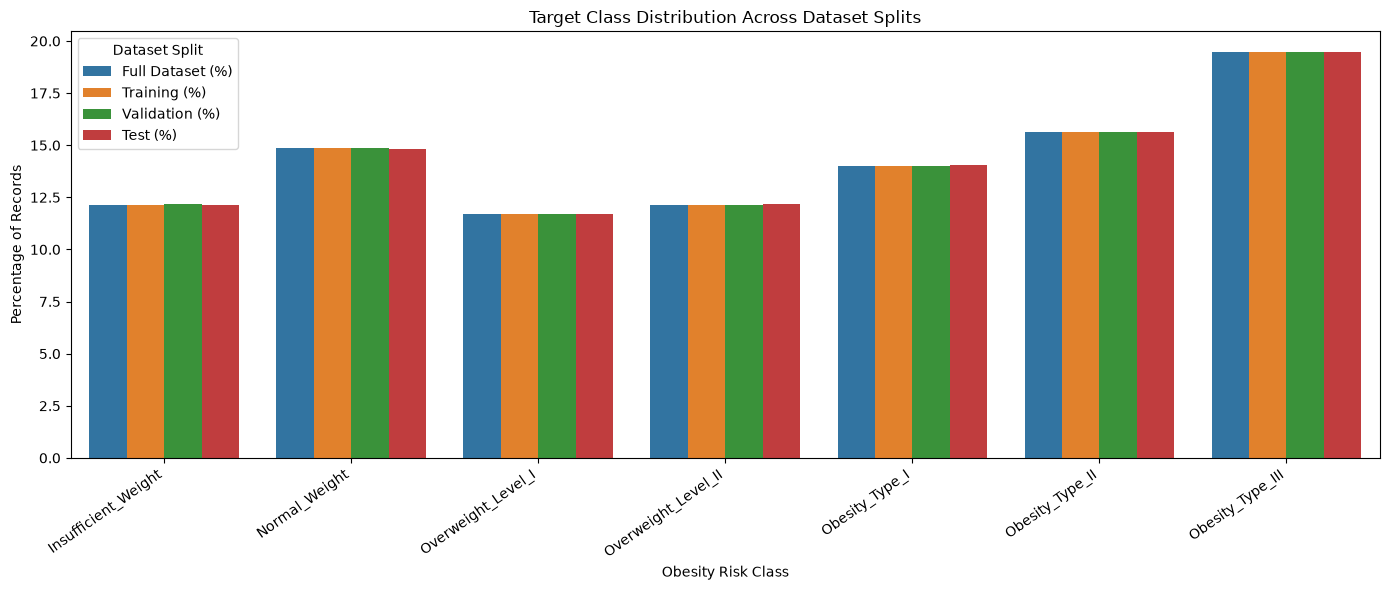

In [173]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=distribution_chart_long,
    x="Obesity Class",
    y="Percentage",
    hue="Dataset Split",
)

plt.title("Target Class Distribution Across Dataset Splits")
plt.xlabel("Obesity Risk Class")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Dataset Split")
plt.tight_layout()
plt.show()